# Urban Site Intelligence — Building Placement Reasoning

**P3 · Road-aligned urban fabric · 30 m × 40 m site · Three urban conditions**

The agent reads the surrounding road network, identifies the primary road and junction type,
then proposes a building typology and footprint with full architectural reasoning.

| Scene | Junction | Road widths | Proposed typology |
|-------|----------|-------------|-------------------|
| **1 — Crossroads Corner** | Crossroads (X) | 5 m alley + 12 m secondary + 20 m main | **H-Building** — longest wing to main road |
| **2 — T-Junction Terminal** | T-junction (T) | 5 m alley + 12 m secondary + 28 m boulevard | **Wide Slab** — long facade faces view axis |
| **3 — Y-Junction Complex** | Y/complex | 4 m path + 15 m secondary + 30 m diagonal | **L-Building** — wraps the corner |

> **Surrounding buildings** are generated road-aligned (plot by plot, following road direction)
> for a realistic urban fabric — no uniform grid.


In [1]:
import os, sys, math
from pathlib import Path
import matplotlib
matplotlib.use('Agg')

_cwd  = Path(os.getcwd()).resolve()
_root = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent] if (p / 'team_04').is_dir()), None
)
if _root is None:
    raise RuntimeError('Cannot find team_04/ from ' + str(_cwd))
for _p in [str(_root), str(_root.parent)]:
    if _p not in sys.path: sys.path.insert(0, _p)
print('Root:', _root)


Root: C:\Users\tuemi\Downloads\Glabtools\IAAC Repo\bimsc26-datamgmt-session03\AIA26_Studio


In [2]:
import warnings, math
from collections import Counter
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from shapely.geometry import LineString, Point, Polygon as SlyPoly
from shapely.ops import unary_union

from team_04.agent.tools.osm_context import (
    fetch_context_or_fallback, build_street_graph, INTERESTING_SITES,
)
from team_04.agent.tools.road_context import analyze_roads
from team_04.agent.tools.site_model import build_site_model
from team_04.agent.tools.urban_analysis import (
    full_urban_analysis, compute_centrality, compute_urban_importance,
    classify_intersection_advanced, detect_intersections_from_roads,
    SITE_TYPE_LABELS,
)

plt.rcParams.update({
    'figure.facecolor': '#F0F0F0', 'axes.facecolor': '#EBEBEB',
    'font.family': 'sans-serif', 'font.size': 10,
    'figure.dpi': 130, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
print('Imports OK')


Imports OK


In [3]:
import math
from shapely.geometry import LineString, Point, Polygon as SlyPoly
from shapely.ops import unary_union

def _road_poly(road):
    cl = road.get('centerline', []); w = road.get('width_m', 6.0)
    if len(cl) < 2: return None
    try: return LineString(cl).buffer(w/2, cap_style=2, join_style=2)
    except: return None

def _sidewalk_poly(road):
    cl = road.get('centerline', []); w = road.get('width_m', 6.0)
    h = road.get('hierarchy', 'path')
    if len(cl) < 2 or h == 'path': return None
    sw = 3.5 if h == 'main' else 2.5
    try:
        return (LineString(cl).buffer(w/2+sw, cap_style=2, join_style=2)
                .difference(LineString(cl).buffer(w/2, cap_style=2, join_style=2)))
    except: return None

def _draw_poly(ax, geom, fc='#CCC', ec='none', alpha=1.0, lw=0.5, zorder=1):
    if geom is None or geom.is_empty: return
    polys = [geom] if geom.geom_type == 'Polygon' else list(getattr(geom, 'geoms', []))
    for p in polys:
        if hasattr(p, 'exterior'):
            xs, ys = p.exterior.xy
            ax.fill(xs, ys, fc=fc, ec=ec, alpha=alpha, linewidth=lw, zorder=zorder)

def _vis_color(s):
    return '#{:02X}{:02X}{:02X}'.format(
        int(244+(42-244)*s), int(226+(157-226)*s), int(133+(143-133)*s))

def _imp_color(s):
    t = max(0, min(1, s))
    return '#{:02X}{:02X}{:02X}'.format(
        int(30+(255-30)*t), int(100+(215-100)*t), int(255+(0-255)*t))

def _bc_color(s, mn=0, mx=1):
    t = max(0, min(1, (s-mn)/(mx-mn+1e-9)))
    return '#{:02X}{:02X}{:02X}'.format(
        int(37+(212-37)*t), int(99+(37-99)*t), int(212+(37-212)*t))

def _draw_cone(ax, apex, dir_deg, half=45, dist=70, fc='#FFD70022', ec='#FFD700', lw=1.0, z=4):
    ang_c = math.radians(dir_deg)
    ang1 = ang_c - math.radians(half); ang2 = ang_c + math.radians(half)
    xs = [apex[0]]; ys = [apex[1]]
    for i in range(21):
        a = ang1 + (ang2-ang1)*i/20
        xs.append(apex[0]+dist*math.cos(a)); ys.append(apex[1]+dist*math.sin(a))
    xs.append(apex[0]); ys.append(apex[1])
    ax.fill(xs, ys, fc=fc, ec=ec, lw=lw, zorder=z)

def _outward_dir(p1, p2, site_cx, site_cy):
    dx, dy = p2[0]-p1[0], p2[1]-p1[1]; L = math.hypot(dx,dy)+1e-9
    nxv, nyv = -dy/L, dx/L
    midx, midy = (p1[0]+p2[0])/2, (p1[1]+p2[1])/2
    if nxv*(midx-site_cx)+nyv*(midy-site_cy) < 0: nxv, nyv = -nxv, -nyv
    return math.degrees(math.atan2(nyv, nxv))

HIER_OSM  = {'main': 1.0, 'secondary': 0.5, 'path': 0.2}
HIER_AF   = {'main': 0.7, 'secondary': 0.4, 'path': 0.1}
HIER_RANK = {'main': 1, 'secondary': 2, 'path': 3}

def _road_importance(road, bc_vals, graph, max_bc):
    h   = road.get('hierarchy', 'path')
    osm = HIER_OSM.get(h, 0.2); af = HIER_AF.get(h, 0.1)
    bc = conn = 0.0
    cl = road.get('centerline', [])
    if cl and bc_vals and graph is not None and len(graph.nodes) > 0:
        mid = cl[len(cl)//2]
        try:
            nid  = min(graph.nodes(), key=lambda n: (graph.nodes[n]['x']-mid[0])**2+(graph.nodes[n]['y']-mid[1])**2)
            bc   = bc_vals.get(nid, 0)/(max_bc or 1)
            conn = min(graph.degree(nid)/8.0, 1.0)
        except: pass
    return round(osm*0.40 + bc*0.30 + conn*0.20 + af*0.10, 4)

def _gen_urban_fabric(roads, site_poly, road_union, seed=7):
    """
    Generate road-aligned buildings that look like real urban fabric.
    Buildings follow the road direction, vary in width/depth, and have
    small gaps between them — far more realistic than a regular grid.
    """
    import random
    rng = random.Random(seed)
    buildings = []

    for road in roads:
        h   = road.get('hierarchy', 'path')
        w   = road.get('width_m', 6.0)
        cl  = road.get('centerline', [])
        if len(cl) < 2: continue

        line = LineString(cl)
        road_len = line.length

        # Building parameters per hierarchy
        if h == 'main':
            b_d_range  = (12, 20)   # depth range (m)
            b_w_range  = (10, 24)   # width (plot frontage)
            gap_range  = (0.8, 2.5) # gap between buildings
            setback    = 1.5        # from road edge
        elif h == 'secondary':
            b_d_range  = (9, 16)
            b_w_range  = (7, 18)
            gap_range  = (1.0, 3.5)
            setback    = 1.2
        else:
            continue   # no buildings generated along paths

        for side in (1, -1):          # both sides of the road
            x_pos = rng.uniform(4, 10)  # random start offset

            while x_pos < road_len - 6:
                b_w = rng.uniform(*b_w_range)
                b_d = rng.uniform(*b_d_range)
                if x_pos + b_w > road_len: break

                # Get road direction at this position
                pt_s = line.interpolate(x_pos)
                pt_e = line.interpolate(min(x_pos + b_w, road_len - 0.1))
                dx   = pt_e.x - pt_s.x; dy = pt_e.y - pt_s.y
                L    = math.hypot(dx, dy) + 1e-9
                # Outward perpendicular
                nx = -dy/L * side; ny = dx/L * side

                road_offset = w/2 + setback

                # Building footprint (parallelogram aligned to road)
                p1 = (pt_s.x + nx*road_offset,        pt_s.y + ny*road_offset)
                p2 = (pt_e.x + nx*road_offset,        pt_e.y + ny*road_offset)
                p3 = (pt_e.x + nx*(road_offset+b_d),  pt_e.y + ny*(road_offset+b_d))
                p4 = (pt_s.x + nx*(road_offset+b_d),  pt_s.y + ny*(road_offset+b_d))

                # Slight taper on one side for organic feel
                taper = rng.uniform(-0.5, 0.5)
                p3 = (p3[0] + nx*taper, p3[1] + ny*taper)

                try:
                    bpoly = SlyPoly([p1, p2, p3, p4])
                    if not bpoly.is_valid: bpoly = bpoly.buffer(0)
                    if bpoly.is_empty: raise ValueError
                    # Skip if it clips the road surface or the site
                    if road_union and road_union.buffer(0.5).intersects(bpoly): raise ValueError
                    if site_poly  and site_poly.buffer(2.0).intersects(bpoly):  raise ValueError
                    buildings.append({
                        'building_type': 'unknown',
                        'polygon_pts': list(bpoly.exterior.coords),
                        'name': None,
                    })
                except Exception:
                    pass

                x_pos += b_w + rng.uniform(*gap_range)

    return buildings

def _trees_along_roads(roads, spacing=8.5, site_poly=None):
    out = []
    for road in roads:
        if road.get('hierarchy', 'path') == 'path': continue
        cl = road.get('centerline', []); w = road.get('width_m', 6.0)
        if len(cl) < 2: continue
        line = LineString(cl); h = road.get('hierarchy', 'secondary')
        sw = 3.5 if h == 'main' else 2.5; off = w/2 + sw*0.55
        n = max(1, int(line.length/spacing))
        for i in range(n):
            t   = (i+0.4)/n*line.length; pt = line.interpolate(t)
            t2  = min(t+0.5, line.length-0.01); p2 = line.interpolate(t2)
            dx, dy = p2.x-pt.x, p2.y-pt.y; L = math.hypot(dx,dy)+1e-9
            nxv, nyv = -dy/L, dx/L
            for s in (1, -1):
                tx, ty = pt.x+s*nxv*off, pt.y+s*nyv*off
                if site_poly and site_poly.buffer(3).contains(Point(tx,ty)): continue
                out.append([tx, ty])
    return out

print('Helpers v3 ready — road-aligned urban fabric generator loaded')


Helpers v3 ready — road-aligned urban fabric generator loaded


In [4]:
"""
Building Placement Engine — proposes a building footprint on the site
based on road hierarchy, junction type, and urban importance.

Rules embedded:
  H-building  → longest wing parallel to primary road (commercial frontage)
  Wide slab   → long facade faces the T-junction view axis
  L-building  → two wings: one to primary road, one to secondary road
  Tower       → centroid shift toward primary road corner
"""
import math
from shapely.geometry import Polygon as SlyPoly, box as _box
from shapely.ops import unary_union


# ── Geometry helpers ──────────────────────────────────────────────────────────

def _rotate_pt(x, y, cx, cy, angle_deg):
    """Rotate point (x,y) around centre (cx,cy)."""
    a = math.radians(angle_deg)
    dx, dy = x - cx, y - cy
    return cx + dx*math.cos(a) - dy*math.sin(a), cy + dx*math.sin(a) + dy*math.cos(a)

def _rotate_poly(poly, cx, cy, angle_deg):
    """Return a new Polygon with all exterior coords rotated."""
    if poly is None or poly.is_empty: return poly
    pts = [_rotate_pt(x, y, cx, cy, angle_deg) for x, y in poly.exterior.coords]
    return SlyPoly(pts)

def _site_bounds(site_bdry):
    pts = [(p[0], p[1]) for p in site_bdry]
    xs  = [p[0] for p in pts]; ys = [p[1] for p in pts]
    return min(xs), min(ys), max(xs), max(ys)   # xmin, ymin, xmax, ymax


def _grid_angle_deg(road):
    """
    Angle of the primary road in degrees from East (0° = E-W, 90° = N-S).
    Returns 0.0 if the centerline is undefined.
    """
    cl = road.get('centerline', [])
    if len(cl) < 2: return 0.0
    dx = cl[-1][0] - cl[0][0]
    dy = cl[-1][1] - cl[0][1]
    return math.degrees(math.atan2(dy, dx))


def _main_facing(site_bdry, road):
    """
    Which site edge is CLOSEST to the primary road centerline?
    Returns 'S', 'N', 'E', or 'W'.
    """
    xmin, ymin, xmax, ymax = _site_bounds(site_bdry)
    cx = (xmin+xmax)/2; cy = (ymin+ymax)/2

    cl = road.get('centerline', [])
    if not cl: return 'S'
    # Sample 5 evenly spaced points along the road centerline
    n = min(len(cl), 5)
    pts = [cl[int(i*(len(cl)-1)/(n-1))] for i in range(n)]

    # Distance from each site edge to road midpoints
    def _edge_dist(edge_pts, road_pts):
        from shapely.geometry import LineString, Point
        edge = LineString(edge_pts)
        return min(edge.distance(Point(p)) for p in road_pts)

    edges = {
        'S': [(xmin, ymin), (xmax, ymin)],
        'N': [(xmin, ymax), (xmax, ymax)],
        'W': [(xmin, ymin), (xmin, ymax)],
        'E': [(xmax, ymin), (xmax, ymax)],
    }
    return min(edges, key=lambda k: _edge_dist(edges[k], pts))


# ── Typology generators ───────────────────────────────────────────────────────

def _make_H(site_bdry, primary_road):
    """
    H-building: two parallel long wings connected by a central crossbar.
    RULE: Wing A (longest) is placed adjacent to the primary road — commercial frontage.
    Wing B is the rear wing — quieter office/residential program.
    Connector is the central crossbar linking the two wings.
    """
    xmin, ymin, xmax, ymax = _site_bounds(site_bdry)
    cx = (xmin+xmax)/2; cy = (ymin+ymax)/2
    sw = xmax-xmin; sd = ymax-ymin

    mf = _main_facing(site_bdry, primary_road)

    # Proportions
    sb       = 2.5           # setback from site edge
    wing_d   = min(8.0, sd*0.20)  # wing depth
    wing_l   = sw - sb*2         # wing length (full width minus setbacks)
    conn_w   = min(9.0, sw*0.28) # connector width
    # Connector depth = gap between Wing A and Wing B minus their own depths
    gap_d    = sd - sb*2 - wing_d*2
    gap_d    = max(gap_d, 4.0)   # ensure minimum courtyard

    if mf == 'S':
        # Wing A — south (primary road facing), commercial
        wA  = _box(cx-wing_l/2, ymin+sb,          cx+wing_l/2, ymin+sb+wing_d)
        # Wing B — north (rear), quiet
        wB  = _box(cx-wing_l/2, ymax-sb-wing_d,   cx+wing_l/2, ymax-sb)
        # Connector — central crossbar
        conn= _box(cx-conn_w/2, ymin+sb+wing_d,   cx+conn_w/2, ymax-sb-wing_d)
        A_prog = 'Wing A — Commercial retail / active ground floor'
        B_prog = 'Wing B — Office / residential / quieter program'
        A_cx, A_cy   = cx, ymin+sb+wing_d/2
        B_cx, B_cy   = cx, ymax-sb-wing_d/2
        co_cx, co_cy = cx, cy
        A_dir_deg    = 270   # arrow pointing south toward main road
        B_dir_deg    = 90    # arrow pointing north toward quiet side
        courtyard_open = 'East and West'
    elif mf == 'N':
        wA  = _box(cx-wing_l/2, ymax-sb-wing_d,   cx+wing_l/2, ymax-sb)
        wB  = _box(cx-wing_l/2, ymin+sb,          cx+wing_l/2, ymin+sb+wing_d)
        conn= _box(cx-conn_w/2, ymin+sb+wing_d,   cx+conn_w/2, ymax-sb-wing_d)
        A_prog = 'Wing A — Commercial retail / active ground floor'
        B_prog = 'Wing B — Office / residential / quieter program'
        A_cx, A_cy   = cx, ymax-sb-wing_d/2
        B_cx, B_cy   = cx, ymin+sb+wing_d/2
        co_cx, co_cy = cx, cy
        A_dir_deg    = 90; B_dir_deg = 270
        courtyard_open = 'East and West'
    elif mf == 'W':
        # Rotate H 90° — wings now run N-S
        wing_l2 = sd - sb*2
        wA  = _box(xmin+sb,          cy-wing_l2/2, xmin+sb+wing_d,         cy+wing_l2/2)
        wB  = _box(xmax-sb-wing_d,   cy-wing_l2/2, xmax-sb,                cy+wing_l2/2)
        conn= _box(xmin+sb+wing_d,   cy-conn_w/2,  xmax-sb-wing_d,         cy+conn_w/2)
        A_prog = 'Wing A — Commercial retail / active ground floor'
        B_prog = 'Wing B — Office / residential / quieter program'
        A_cx, A_cy   = xmin+sb+wing_d/2, cy
        B_cx, B_cy   = xmax-sb-wing_d/2, cy
        co_cx, co_cy = cx, cy
        A_dir_deg    = 180; B_dir_deg = 0
        courtyard_open = 'North and South'
    else:  # 'E'
        wing_l2 = sd - sb*2
        wA  = _box(xmax-sb-wing_d,   cy-wing_l2/2, xmax-sb,                cy+wing_l2/2)
        wB  = _box(xmin+sb,          cy-wing_l2/2, xmin+sb+wing_d,         cy+wing_l2/2)
        conn= _box(xmin+sb+wing_d,   cy-conn_w/2,  xmax-sb-wing_d,         cy+conn_w/2)
        A_prog = 'Wing A — Commercial retail / active ground floor'
        B_prog = 'Wing B — Office / residential / quieter program'
        A_cx, A_cy   = xmax-sb-wing_d/2, cy
        B_cx, B_cy   = xmin+sb+wing_d/2, cy
        co_cx, co_cy = cx, cy
        A_dir_deg    = 0; B_dir_deg = 180
        courtyard_open = 'North and South'

    footprint = unary_union([wA, wB, conn])
    coverage  = footprint.area / (sw*sd)
    far_est   = coverage * 4   # 4-storey estimate

    grid_angle = _grid_angle_deg(primary_road)
    pname = primary_road.get('name') or 'primary road'
    pwidth= primary_road.get('width_m', 20)

    reasoning = [
        f"Grid angle: {grid_angle:.0f} deg (from {pname})",
        f"Primary road '{pname}' ({pwidth:.0f} m) is to the {mf}.",
        "RULE: longest wing parallel to primary road → Wing A faces " + mf + ".",
        f"Wing A ({wing_l:.0f} m long x {wing_d:.0f} m deep): {A_prog.split('—')[1].strip()}",
        f"Wing B ({wing_l:.0f} m long x {wing_d:.0f} m deep): {B_prog.split('—')[1].strip()}",
        f"Connector ({conn_w:.0f} m wide): vertical circulation, structural core.",
        f"Courtyard opens to {courtyard_open} — daylight to all wings.",
        f"Coverage: {coverage:.0%}  |  Est. FAR (4 floors): {far_est:.1f}",
    ]

    return dict(
        typology='H-Building', grid_angle=grid_angle, main_facing=mf,
        wing_A=wA, wing_B=wB, connector=conn, footprint=footprint,
        A_label='WING A', B_label='WING B', conn_label='CONNECTOR',
        A_program=A_prog, B_program=B_prog,
        A_center=(A_cx, A_cy), B_center=(B_cx, B_cy), conn_center=(co_cx, co_cy),
        A_dir_deg=A_dir_deg, B_dir_deg=B_dir_deg,
        coverage=coverage, far_est=far_est, reasoning=reasoning,
        courtyard_open=courtyard_open,
    )


def _make_slab(site_bdry, primary_road, face_axis=False):
    """
    Wide slab: single long block with one primary public facade.
    Used for T-junction terminals — the building addresses the view axis.
    face_axis=True shifts the slab toward the axis end.
    """
    xmin, ymin, xmax, ymax = _site_bounds(site_bdry)
    cx = (xmin+xmax)/2; cy = (ymin+ymax)/2
    sw = xmax-xmin; sd = ymax-ymin

    mf = _main_facing(site_bdry, primary_road)
    sb = 2.5

    if mf in ('S', 'N'):
        slab_d = min(sd*0.60, 22)
        slab_l = sw - sb*2
        if mf == 'S':
            y0 = ymin+sb; y1 = y0+slab_d
        else:
            y1 = ymax-sb; y0 = y1-slab_d
        slab = _box(cx-slab_l/2, y0, cx+slab_l/2, y1)
        A_cx, A_cy = cx, (y0+y1)/2
        A_dir_deg  = 270 if mf=='S' else 90
    else:
        slab_l = min(sw*0.60, 22)
        slab_d = sd - sb*2
        if mf == 'W':
            x0 = xmin+sb; x1 = x0+slab_l
        else:
            x1 = xmax-sb; x0 = x1-slab_l
        slab = _box(x0, ymin+sb, x1, ymax-sb)
        A_cx, A_cy = (x0+x1)/2, cy
        A_dir_deg  = 180 if mf=='W' else 0

    footprint = slab
    coverage  = footprint.area / (sw*sd)
    far_est   = coverage * 5

    grid_angle = _grid_angle_deg(primary_road)
    pname = primary_road.get('name') or 'primary road'
    pwidth = primary_road.get('width_m', 20)

    reasoning = [
        f"Grid angle: {grid_angle:.0f} deg (from {pname})",
        f"Primary road '{pname}' ({pwidth:.0f} m) is to the {mf}.",
        "RULE: T-junction terminal — long facade faces the VIEW AXIS.",
        f"Slab ({slab_l if mf in ('E','W') else sw-sb*2:.0f} m long): primary public facade toward junction.",
        "Slender profile maximises floor count and reinforces the visual axis.",
        "All building services face the rear (quieter side).",
        f"Coverage: {coverage:.0%}  |  Est. FAR (5 floors): {far_est:.1f}",
    ]

    return dict(
        typology='Wide Slab', grid_angle=grid_angle, main_facing=mf,
        wing_A=slab, wing_B=None, connector=None, footprint=footprint,
        A_label='SLAB FACADE', B_label='', conn_label='',
        A_program='Primary facade — addresses T-junction view axis',
        B_program='Rear service / secondary access',
        A_center=(A_cx, A_cy), B_center=(cx, cy), conn_center=(cx, cy),
        A_dir_deg=A_dir_deg, B_dir_deg=None,
        coverage=coverage, far_est=far_est, reasoning=reasoning,
        courtyard_open=None,
    )


def _make_L(site_bdry, primary_road, secondary_road=None):
    """
    L-building: one wing to the primary road, one perpendicular to secondary.
    Used for corner sites where the L 'wraps' the corner.
    """
    xmin, ymin, xmax, ymax = _site_bounds(site_bdry)
    cx = (xmin+xmax)/2; cy = (ymin+ymax)/2
    sw = xmax-xmin; sd = ymax-ymin

    mf = _main_facing(site_bdry, primary_road)
    sb = 2.5

    # Determine the secondary facing (90 degrees from primary)
    # Try to find it from secondary road; otherwise default
    if secondary_road:
        sf = _main_facing(site_bdry, secondary_road)
    else:
        # default: clockwise from main
        sf = {'S':'W', 'W':'N', 'N':'E', 'E':'S'}[mf]

    arm_d = min(8.0, sw*0.25)  # arm depth

    if mf == 'S' and sf == 'W':
        # Horizontal arm along south (primary), vertical arm along west (secondary)
        armA = _box(xmin+sb, ymin+sb, xmax-sb,    ymin+sb+arm_d)
        armB = _box(xmin+sb, ymin+sb, xmin+sb+arm_d, ymax-sb)
        A_cx, A_cy = cx, ymin+sb+arm_d/2
        B_cx, B_cy = xmin+sb+arm_d/2, cy
        A_dir_deg  = 270; B_dir_deg = 180
    elif mf == 'S' and sf == 'E':
        armA = _box(xmin+sb, ymin+sb, xmax-sb,     ymin+sb+arm_d)
        armB = _box(xmax-sb-arm_d, ymin+sb, xmax-sb, ymax-sb)
        A_cx, A_cy = cx, ymin+sb+arm_d/2
        B_cx, B_cy = xmax-sb-arm_d/2, cy
        A_dir_deg  = 270; B_dir_deg = 0
    elif mf == 'W' and sf == 'S':
        armA = _box(xmin+sb, ymin+sb, xmin+sb+arm_d, ymax-sb)
        armB = _box(xmin+sb, ymin+sb, xmax-sb, ymin+sb+arm_d)
        A_cx, A_cy = xmin+sb+arm_d/2, cy
        B_cx, B_cy = cx, ymin+sb+arm_d/2
        A_dir_deg  = 180; B_dir_deg = 270
    else:
        # Generic fallback: L in SW corner
        armA = _box(xmin+sb, ymin+sb, xmax-sb, ymin+sb+arm_d)
        armB = _box(xmin+sb, ymin+sb, xmin+sb+arm_d, ymax-sb)
        A_cx, A_cy = cx, ymin+sb+arm_d/2
        B_cx, B_cy = xmin+sb+arm_d/2, cy
        A_dir_deg = 270; B_dir_deg = 180

    footprint = unary_union([armA, armB])
    coverage  = footprint.area / (sw*sd)
    far_est   = coverage * 5

    grid_angle = _grid_angle_deg(primary_road)
    pname = primary_road.get('name') or 'primary road'
    pwidth = primary_road.get('width_m', 20)
    sec_name = secondary_road.get('name') or 'secondary road' if secondary_road else 'secondary road'

    reasoning = [
        f"Grid angle: {grid_angle:.0f} deg (from {pname})",
        f"Corner site: '{pname}' ({pwidth:.0f} m) is to the {mf}, '{sec_name}' to the {sf}.",
        "RULE: L-building wraps the corner — Arm A faces primary road, Arm B faces secondary.",
        f"Arm A ({sw-sb*2:.0f} m long): Primary facade — commercial ground floor toward {pname}.",
        f"Arm B ({sd-sb*2:.0f} m long): Secondary facade — office / mixed-use toward {sec_name}.",
        "Corner junction: activate corner with recessed entrance or chamfered edge.",
        "Open courtyard: fills the L interior — passive ventilation and light.",
        f"Coverage: {coverage:.0%}  |  Est. FAR (5 floors): {far_est:.1f}",
    ]

    return dict(
        typology='L-Building', grid_angle=grid_angle, main_facing=mf,
        wing_A=armA, wing_B=armB, connector=None, footprint=footprint,
        A_label='ARM A', B_label='ARM B', conn_label='',
        A_program='Arm A — Commercial / primary frontage',
        B_program='Arm B — Office / secondary frontage',
        A_center=(A_cx, A_cy), B_center=(B_cx, B_cy), conn_center=((A_cx+B_cx)/2,(A_cy+B_cy)/2),
        A_dir_deg=A_dir_deg, B_dir_deg=B_dir_deg,
        coverage=coverage, far_est=far_est, reasoning=reasoning,
        courtyard_open='Interior L-courtyard',
        secondary_facing=sf,
    )


# ── Main proposal dispatcher ──────────────────────────────────────────────────

IX_TYPOLOGY = {
    # junction_type → (building_typology, function_key)
    'crossroads':       ('H-Building',  'H'),
    't_junction':       ('Wide Slab',   'slab'),
    'y_junction':       ('L-Building',  'L'),
    'complex_junction': ('H-Building',  'H'),
    'roundabout':       ('H-Building',  'H'),
    'dead_end':         ('Wide Slab',   'slab'),
    'bend':             ('L-Building',  'L'),
}

def propose_building(site_bdry, primary_road, site_type, importance_score,
                     secondary_road=None, junction_type=None):
    """
    Dispatch to the correct typology based on site context.
    Returns the placement dict from _make_H / _make_slab / _make_L.
    """
    # Choose typology
    if junction_type and junction_type in IX_TYPOLOGY:
        _, key = IX_TYPOLOGY[junction_type]
    elif site_type in ('t_junction_terminal',):
        key = 'slab'
    elif site_type in ('corner', 'triangular_corner'):
        key = 'L'
    else:
        key = 'H'    # default: H-building

    # Override by importance: very high importance → always H (landmark)
    if importance_score >= 0.70:
        key = 'H'

    if key == 'H':
        return _make_H(site_bdry, primary_road)
    elif key == 'slab':
        return _make_slab(site_bdry, primary_road)
    else:
        return _make_L(site_bdry, primary_road, secondary_road)

print('Building placement engine ready')
print('  Typologies: H-Building (crossroads/complex) | Wide Slab (T-junction) | L-Building (corner/Y)')


Building placement engine ready
  Typologies: H-Building (crossroads/complex) | Wide Slab (T-junction) | L-Building (corner/Y)


In [5]:
# ============================================================
# Three synthetic urban scenes — rich road networks
# All use 30 m x 40 m site at centre (0,0) → x: -15..15, y: -20..20
# ============================================================
# Road hierarchy widths per scene:
#   Scene 1 (crossroads corner)  : 5 m + 12 m + 20 m
#   Scene 2 (T-junction terminal): 5 m + 12 m + 28 m
#   Scene 3 (Y-junction complex) : 4 m + 15 m + 30 m diagonal
# ============================================================

SITE_BDRY = [[-15,-20],[15,-20],[15,20],[-15,20],[-15,-20]]

# ── Scene 1: Crossroads Corner (Barcelona / Paris style) ──────────────────────
# Site sits at the corner of a 20 m main road (south) and a 12 m secondary (west).
# The H-building is the correct typology here.
SCENE_1 = {
    'name'    : 'SCENE 1  |  Crossroads Corner  (H-Building)',
    'junction': 'crossroads',
    'roads'   : [
        # Main road E-W (20 m wide): 12 m south of site bottom
        {'type':'road','centerline':[[-140,-32],[140,-32]],
         'width_m':20.0,'hierarchy':'main','name':'Main Boulevard'},
        # Secondary road N-S W (12 m): 13 m west of site left edge
        {'type':'road','centerline':[[-28,-140],[-28,140]],
         'width_m':12.0,'hierarchy':'secondary','name':'West Street'},
        # Secondary road N-S E (12 m): 17 m east of site right edge
        {'type':'road','centerline':[[32,-140],[32,140]],
         'width_m':12.0,'hierarchy':'secondary','name':'East Street'},
        # Secondary road E-W N (12 m): 18 m north of site top
        {'type':'road','centerline':[[-140,38],[140,38]],
         'width_m':12.0,'hierarchy':'secondary','name':'Upper Street'},
        # Service lane just south of site (5 m): parallel to main road
        {'type':'road','centerline':[[-140,-22],[140,-22]],
         'width_m':5.0,'hierarchy':'path','name':'Service Lane'},
        # Narrow alley just west of site (4 m)
        {'type':'road','centerline':[[-17,-140],[-17,140]],
         'width_m':4.5,'hierarchy':'path','name':'West Alley'},
    ],
    'intersections': [
        {'point':[-28,-32],'degree':4,'type':'crossroads'},
        {'point':[32,-32], 'degree':4,'type':'crossroads'},
        {'point':[-28,38], 'degree':4,'type':'crossroads'},
        {'point':[32,38],  'degree':4,'type':'crossroads'},
        {'point':[-17,-32],'degree':3,'type':'t_junction'},
        {'point':[-17,38], 'degree':3,'type':'t_junction'},
        {'point':[-28,-22],'degree':3,'type':'t_junction'},
        {'point':[32,-22], 'degree':3,'type':'t_junction'},
    ],
}

# ── Scene 2: T-Junction Terminal (London / Bloomsbury style) ──────────────────
# Site sits at the END of a secondary street that terminates on a main boulevard.
# The building forms a visual terminus. Wide slab faces the view axis.
SCENE_2 = {
    'name'    : 'SCENE 2  |  T-Junction Terminal  (Wide Slab)',
    'junction': 't_junction',
    'roads'   : [
        # Main boulevard E-W (28 m wide): 18 m south of site bottom
        {'type':'road','centerline':[[-160,-38],[160,-38]],
         'width_m':28.0,'hierarchy':'main','name':'Grand Boulevard'},
        # Terminus street N-S (12 m): ENDS at the boulevard, runs away from site south
        {'type':'road','centerline':[[0,-38],[0,-130]],
         'width_m':12.0,'hierarchy':'secondary','name':'Terminus Road'},
        # Secondary street E-W (12 m): north of site
        {'type':'road','centerline':[[-160,42],[160,42]],
         'width_m':12.0,'hierarchy':'secondary','name':'North Cross Street'},
        # Secondary N-S E (12 m)
        {'type':'road','centerline':[[45,-160],[45,160]],
         'width_m':12.0,'hierarchy':'secondary','name':'East Road'},
        # Secondary N-S W (12 m)
        {'type':'road','centerline':[[-45,-160],[-45,160]],
         'width_m':12.0,'hierarchy':'secondary','name':'West Road'},
        # Service alley W of site
        {'type':'road','centerline':[[-18,-160],[-18,160]],
         'width_m':4.5,'hierarchy':'path','name':'West Alley'},
        # Service alley E of site
        {'type':'road','centerline':[[18,-160],[18,160]],
         'width_m':4.5,'hierarchy':'path','name':'East Alley'},
    ],
    'intersections': [
        # T-junction: where terminus road meets the boulevard
        {'point':[0,-38], 'degree':3,'type':'t_junction'},
        {'point':[45,-38],'degree':4,'type':'crossroads'},
        {'point':[-45,-38],'degree':4,'type':'crossroads'},
        {'point':[45,42], 'degree':4,'type':'crossroads'},
        {'point':[-45,42],'degree':4,'type':'crossroads'},
        {'point':[18,-38],'degree':3,'type':'t_junction'},
        {'point':[-18,-38],'degree':3,'type':'t_junction'},
        {'point':[18,42], 'degree':3,'type':'t_junction'},
        {'point':[-18,42],'degree':3,'type':'t_junction'},
    ],
}

# ── Scene 3: Y-Junction / Complex (Istanbul Beyoglu / Paris diagonal style) ───
# Diagonal avenue (30 m) crosses a main boulevard (28 m) creating a complex star
# junction south-west of the site. L-building wraps the site corner.
SCENE_3 = {
    'name'    : 'SCENE 3  |  Y-Junction Complex  (L-Building)',
    'junction': 'y_junction',
    'roads'   : [
        # Grand boulevard E-W (28 m): 18 m south of site bottom
        {'type':'road','centerline':[[-160,-38],[160,-38]],
         'width_m':28.0,'hierarchy':'main','name':'Grand Boulevard'},
        # Diagonal avenue (25 m) at ~37 deg: (-70,-95) → (85,75)
        # At y=-38: x ≈ -70 + ((-38+95)/170)*155 = -70 + 0.335*155 = -70+52 = -18
        {'type':'road','centerline':[[-70,-95],[85,75]],
         'width_m':25.0,'hierarchy':'main','name':'Avenue Diagonale'},
        # Secondary E-W north (15 m)
        {'type':'road','centerline':[[-160,45],[160,45]],
         'width_m':15.0,'hierarchy':'secondary','name':'Rue Transversale'},
        # Secondary N-S east (15 m)
        {'type':'road','centerline':[[48,-160],[48,160]],
         'width_m':15.0,'hierarchy':'secondary','name':'Rue Perpendiculaire'},
        # Short secondary connector N-S between boulevard and transversale (12 m)
        {'type':'road','centerline':[[0,-38],[0,45]],
         'width_m':12.0,'hierarchy':'secondary','name':'Rue Centrale'},
        # Service alley W of site (4 m)
        {'type':'road','centerline':[[-18,-160],[-18,160]],
         'width_m':4.5,'hierarchy':'path','name':'Ruelle Ouest'},
        # Service path parallel to diagonal (4 m)
        {'type':'road','centerline':[[-55,-55],[70,60]],
         'width_m':4.0,'hierarchy':'path','name':'Passage Diagonal'},
    ],
    'intersections': [
        # Complex star where diagonal meets boulevard near x=-18, y=-38
        {'point':[-18,-38],'degree':5,'type':'complex_junction'},
        # Crossroads: boulevard x N-S secondary
        {'point':[48,-38], 'degree':4,'type':'crossroads'},
        # T-junction: connector meets boulevard
        {'point':[0,-38],  'degree':3,'type':'t_junction'},
        # Crossroads: transversale x N-S secondary
        {'point':[48,45],  'degree':4,'type':'crossroads'},
        {'point':[0,45],   'degree':4,'type':'crossroads'},
        # T-junction: alley meets transversale
        {'point':[-18,45], 'degree':3,'type':'t_junction'},
        # Where diagonal crosses transversale
        {'point':[30,45],  'degree':3,'type':'y_junction'},
    ],
}

SCENES = [SCENE_1, SCENE_2, SCENE_3]
print(f'{len(SCENES)} scenes defined')
for sc in SCENES:
    hc = {}
    for r in sc['roads']:
        h = r.get('hierarchy','?')
        hc[h] = hc.get(h, 0) + 1
    print(f"  {sc['name'][:45]}: {len(sc['roads'])} roads "
          f"(main={hc.get('main',0)} sec={hc.get('secondary',0)} path={hc.get('path',0)}) "
          f"{len(sc['intersections'])} junctions")


3 scenes defined
  SCENE 1  |  Crossroads Corner  (H-Building): 6 roads (main=1 sec=3 path=2) 8 junctions
  SCENE 2  |  T-Junction Terminal  (Wide Slab): 7 roads (main=1 sec=4 path=2) 9 junctions
  SCENE 3  |  Y-Junction Complex  (L-Building): 7 roads (main=2 sec=3 path=2) 7 junctions


In [6]:
from collections import Counter
import networkx as nx
from shapely.geometry import LineString, Point, Polygon as SlyPoly
from shapely.ops import unary_union

_SITE_POLY = SlyPoly([(p[0],p[1]) for p in SITE_BDRY])
SITE_CX, SITE_CY = _SITE_POLY.centroid.x, _SITE_POLY.centroid.y

scene_results = {}

for sc in SCENES:
    name   = sc['name']
    roads  = sc['roads']
    ix_raw = sc['intersections']
    jtype  = sc.get('junction')
    print(f'\n{name}')
    print('-' * 65)

    # ── Site model + road analysis
    sm        = build_site_model(SITE_BDRY)
    sm['roads'] = analyze_roads(sm, roads)
    urban     = full_urban_analysis(sm, roads, ix_raw)

    # ── NetworkX graph + centrality
    try:
        G    = build_street_graph(roads)
        C_NX = compute_centrality(G)
        IMP  = compute_urban_importance(sm, G, C_NX)
        nx_ok= G is not None and bool(C_NX)
    except Exception as _e:
        G, C_NX, IMP, nx_ok = None, {}, {'score':0.5,'grade':'B','factors':{}}, False
        print(f'  NetworkX: {_e}')

    # ── Road importance scoring
    bc_vals = C_NX.get('betweenness', {}) if C_NX else {}
    max_bc  = max(bc_vals.values(), default=1) or 1
    for ri, r in enumerate(roads):
        r['_score'] = _road_importance(r, bc_vals, G if nx_ok else None, max_bc)
        r['_id']    = f'R{ri+1:03d}'
    ranked  = sorted(roads, key=lambda r: -r.get('_score', 0))
    primary = ranked[0] if ranked else None
    # Secondary = second best, preferably perpendicular
    secondary = None
    if len(ranked) >= 2:
        for r in ranked[1:]:
            if r.get('hierarchy') in ('main','secondary'):
                secondary = r; break

    # ── Intersection classification + J-IDs
    for ix in ix_raw:
        if ix.get('degree') == 3 and ix.get('type') in ('t_junction','y_junction', None):
            nr = [r for r in roads
                  if len(r.get('centerline',[])) >= 2
                  and LineString(r['centerline']).distance(Point(ix['point'])) < 12]
            ix['type'] = classify_intersection_advanced(3, nr)
    ix_s = sorted(ix_raw, key=lambda ix: (-ix['point'][1], ix['point'][0]))
    for ji, ix in enumerate(ix_s): ix['_jid'] = f'J{ji+1:03d}'

    # ── Road polygon union (for building clipping)
    rp = [_road_poly(r) for r in roads]; rp = [p for p in rp if p and not p.is_empty]
    ru = unary_union(rp) if rp else None

    # ── Realistic road-aligned surrounding buildings
    bldgs = _gen_urban_fabric(roads, _SITE_POLY, ru, seed=42)

    # ── Trees along main / secondary roads
    trees = _trees_along_roads(roads, spacing=8.5, site_poly=_SITE_POLY)

    # ── Dijkstra to primary road
    path_nodes, path_len = [], float('inf')
    if nx_ok and primary and G.number_of_nodes() > 1:
        try:
            snd = min(G.nodes(), key=lambda n: (G.nodes[n]['x']-SITE_CX)**2+(G.nodes[n]['y']-SITE_CY)**2)
            pcl = primary.get('centerline', [])
            if pcl:
                pm  = pcl[len(pcl)//2]
                pnd = min(G.nodes(), key=lambda n: (G.nodes[n]['x']-pm[0])**2+(G.nodes[n]['y']-pm[1])**2)
                if nx.has_path(G, snd, pnd):
                    path_nodes = nx.shortest_path(G, snd, pnd, weight='length')
                    path_len   = nx.shortest_path_length(G, snd, pnd, weight='length')
        except Exception as _pe:
            print(f'  Dijkstra: {_pe}')

    # ── View bounds
    pts = [p for r in roads for p in r.get('centerline',[])] + list(SITE_BDRY)
    xs  = [p[0] for p in pts]; ys = [p[1] for p in pts]
    vcx = (min(xs)+max(xs))/2; vcy = (min(ys)+max(ys))/2
    vrng= max(max(xs)-min(xs), max(ys)-min(ys))/2*1.2+15
    view= (vcx-vrng, vcy-vrng, vcx+vrng, vcy+vrng)

    # ── Building placement proposal
    dom_jtype = jtype or (
        Counter(ix.get('type') for ix in ix_s).most_common(1)[0][0]
        if ix_s else 'crossroads'
    )
    placement = propose_building(
        SITE_BDRY, primary, urban['site_type'],
        IMP.get('score', 0.5),
        secondary_road=secondary,
        junction_type=dom_jtype,
    )

    scene_results[name] = dict(
        roads=roads, bldgs=bldgs, trees=trees, road_u=ru,
        site_model=sm, urban=urban, importance=IMP,
        G=G, nx_ok=nx_ok, bc_vals=bc_vals, max_bc=max_bc,
        ranked=ranked, primary=primary, secondary=secondary,
        ix_s=ix_s, vcx=vcx, vcy=vcy, vrng=vrng, view=view,
        path_nodes=path_nodes, path_len=path_len,
        placement=placement, dom_jtype=dom_jtype,
    )

    hc   = Counter(r.get('hierarchy') for r in roads)
    ixc  = Counter(ix.get('type') for ix in ix_s)
    p    = placement
    print(f'  Roads: main={hc.get("main",0)} sec={hc.get("secondary",0)} path={hc.get("path",0)}')
    print(f'  Junctions: {dict(ixc)}')
    print(f'  Frontages: {len(urban["frontages"])}  '
          f'Gateways: {sum(1 for c in urban["corner_conditions"] if c.get("is_gateway"))}')
    print(f'  Importance: {IMP.get("grade","?")} ({IMP.get("score",0):.2f})')
    print(f'  Proposed: {p["typology"]}  |  main facing: {p["main_facing"]}  '
          f'|  coverage: {p["coverage"]:.0%}  |  FAR est: {p["far_est"]:.1f}')
    print(f'  Surrounding buildings generated: {len(bldgs)}')



SCENE 1  |  Crossroads Corner  (H-Building)
-----------------------------------------------------------------
  Roads: main=1 sec=3 path=2
  Junctions: {'crossroads': 4, 't_junction': 4}
  Frontages: 4  Gateways: 0
  Importance: B (0.50)
  Proposed: H-Building  |  main facing: S  |  coverage: 47%  |  FAR est: 1.9
  Surrounding buildings generated: 74

SCENE 2  |  T-Junction Terminal  (Wide Slab)
-----------------------------------------------------------------
  Roads: main=1 sec=4 path=2
  Junctions: {'crossroads': 4, 't_junction': 5}
  Frontages: 4  Gateways: 2
  Importance: C (0.40)
  Proposed: Wide Slab  |  main facing: S  |  coverage: 46%  |  FAR est: 2.3
  Surrounding buildings generated: 110

SCENE 3  |  Y-Junction Complex  (L-Building)
-----------------------------------------------------------------
  Roads: main=2 sec=3 path=2
  Junctions: {'t_junction': 3, 'crossroads': 3, 'complex_junction': 1}
  Frontages: 4  Gateways: 2
  Importance: C (0.33)
  Proposed: L-Building  |  m

Figure saved: p3_placement.png


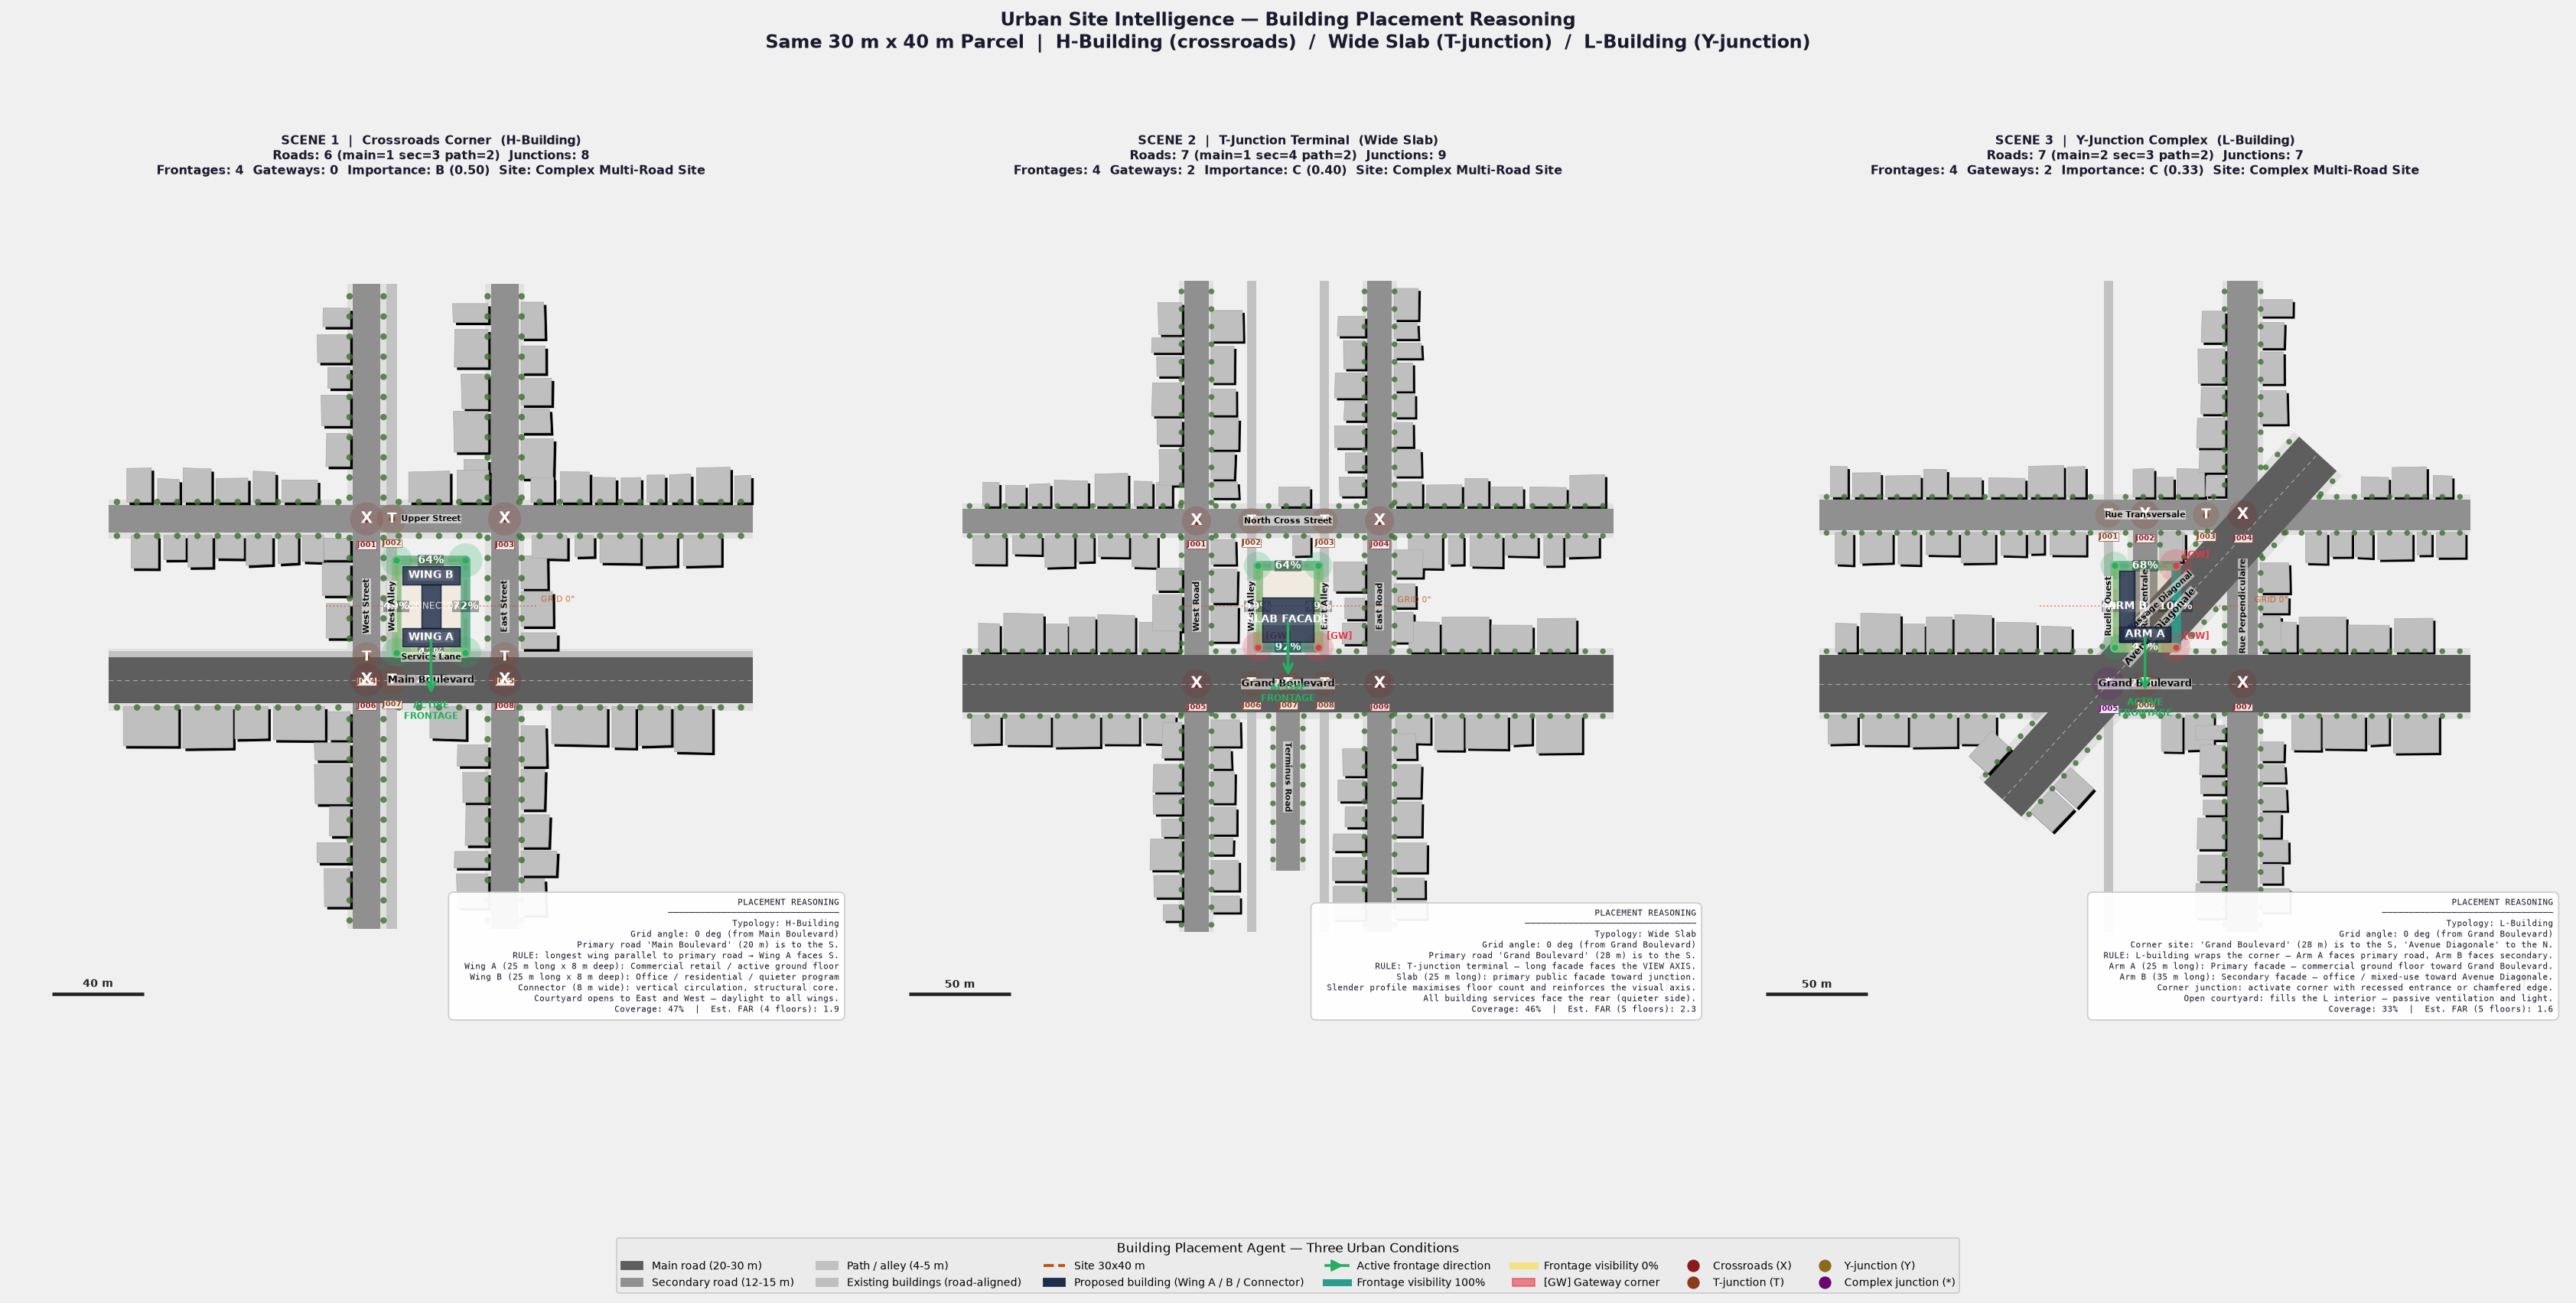

In [7]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from shapely.geometry import Polygon as SlyPoly, Point
from collections import Counter

# ── Colour palette ──────────────────────────────────────────────────────────
_ROAD_GRAY = {'main': '#5E5E5E', 'secondary': '#909090', 'path': '#C2C2C2'}
IX_STYLE   = {
    'crossroads':       ('X', '#8B1A1A', 13),
    't_junction':       ('T', '#8B3A1A', 12),
    'y_junction':       ('Y', '#8B6A1A', 12),
    'complex_junction': ('*', '#6A0572', 12),
    'dead_end':         ('.', '#5A5A5A',  8),
    'bend':             ('.', '#5A5A5A',  7),
    'roundabout':       ('O', '#1A4A8B', 14),
}

# ── Figure layout ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(26, 12))
fig.patch.set_facecolor('#F0F0F0')

for ax, sc in zip(axes, SCENES):
    d   = scene_results[sc['name']]
    roads = d['roads']; bldgs = d['bldgs']; trees = d['trees']
    ru    = d['road_u']; sm    = d['site_model']; urban = d['urban']
    ix_s  = d['ix_s'];   primary = d['primary']
    VIEW  = d['view'];   vrng = d['vrng']
    IMP   = d['importance']
    p     = d['placement']            # building placement dict
    _c    = sm.get('corners', []); _s = sm.get('sides', [])
    front = urban['frontages']; corners = urban['corner_conditions']
    access= urban['access']

    ax.set_aspect('equal'); ax.axis('off')
    ax.set_xlim(VIEW[0], VIEW[2]); ax.set_ylim(VIEW[1], VIEW[3])
    ax.set_facecolor('#EBEBEB')

    # ── 1. Sidewalks ──────────────────────────────────────────────────────
    for road in roads:
        _draw_poly(ax, _sidewalk_poly(road), fc='#E0E0E0', ec='none', zorder=2)

    # ── 2. Road surfaces (hierarchy-coded gray) ───────────────────────────
    for h in ('path', 'secondary', 'main'):
        for road in roads:
            if road.get('hierarchy') == h:
                _draw_poly(ax, _road_poly(road), fc=_ROAD_GRAY[h], ec='none', zorder=3)

    # Centre-line dashes on main roads
    for road in roads:
        if road.get('hierarchy') == 'main':
            cl = road.get('centerline', [])
            if len(cl) >= 2:
                ax.plot([p_[0] for p_ in cl], [p_[1] for p_ in cl],
                        color='white', lw=0.65, dashes=(5, 4), alpha=0.45, zorder=4)

    # Width annotation on primary road (single label)
    if primary:
        pcl = primary.get('centerline', [])
        pw  = primary.get('width_m', 20)
        if len(pcl) >= 2:
            mi  = len(pcl)//2
            mx_ = (pcl[mi][0]+pcl[mi-1][0])/2
            my_ = (pcl[mi][1]+pcl[mi-1][1])/2
            ax.text(mx_, my_, f'{pw:.0f} m',
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold', zorder=10,
                    bbox=dict(fc='#00000060', ec='none', pad=0.3))

    # ── 3. Surrounding buildings (road-aligned, organic) ─────────────────
    for bldg in bldgs:
        pts_ = bldg.get('polygon_pts', [])
        if len(pts_) < 3: continue
        bp = SlyPoly([(p_[0], p_[1]) for p_ in pts_])
        if not bp.is_valid: bp = bp.buffer(0)
        if ru: bp = bp.difference(ru)
        if bp.is_empty: continue
        # Drop shadow
        _draw_poly(ax, SlyPoly([(q[0]+1.2, q[1]-1.2) for q in pts_]),
                   fc='#00000015', ec='none', zorder=5)
        _draw_poly(ax, bp, fc='#BFBFBF', ec='#ABABAB', lw=0.4, zorder=6)

    # ── 4. Street trees ───────────────────────────────────────────────────
    _tr = max(1.4, 2.0 * 100 / vrng)
    for tp in trees:
        if not (VIEW[0] < tp[0] < VIEW[2] and VIEW[1] < tp[1] < VIEW[3]): continue
        if ru and ru.contains(Point(tp)): continue
        ax.add_patch(plt.Circle((tp[0], tp[1]), _tr,
                                 color='#3E7232', alpha=0.82, zorder=9, lw=0))

    # ── 5. Site boundary ──────────────────────────────────────────────────
    sp = SlyPoly([(pt[0], pt[1]) for pt in SITE_BDRY])
    xs_s, ys_s = sp.exterior.xy
    ax.fill(xs_s, ys_s, color='#FF8C00', alpha=0.06, zorder=10)
    ax.plot(xs_s, ys_s, color='#C84800', lw=2.5, dashes=(8, 3), zorder=11)

    # ── 6. Proposed building footprint ────────────────────────────────────
    bldg_color = '#1E2D4A'   # dark navy

    def _draw_wing(polygon, label, program, cx_, cy_, dir_deg):
        if polygon is None or polygon.is_empty: return
        _draw_poly(ax, polygon, fc=bldg_color, ec='#0A1628', alpha=0.82,
                   lw=0.8, zorder=20)
        # Label on the wing
        ax.text(cx_, cy_, label,
                ha='center', va='center', fontsize=7.5,
                color='white', fontweight='bold', zorder=22,
                bbox=dict(fc='#FFFFFF20', ec='none', pad=0.2))

    _draw_wing(p['wing_A'],    p['A_label'], p['A_program'], *p['A_center'], p['A_dir_deg'])
    _draw_wing(p['wing_B'],    p['B_label'], p['B_program'], *p['B_center'],
               p.get('B_dir_deg', 90))
    if p['connector'] is not None and not p['connector'].is_empty:
        _draw_poly(ax, p['connector'], fc=bldg_color, ec='#0A1628',
                   alpha=0.82, lw=0.8, zorder=20)
        ax.text(p['conn_center'][0], p['conn_center'][1],
                p['conn_label'] or 'CONNECTOR',
                ha='center', va='center', fontsize=6.5,
                color='white', alpha=0.8, zorder=22)

    # Active frontage arrows: arrow from Wing A face toward primary road
    if p.get('A_dir_deg') is not None and p['wing_A'] is not None:
        acx, acy = p['A_center']
        adir = math.radians(p['A_dir_deg'])
        al   = vrng * 0.14
        ax.annotate('',
                    xy  =(acx + al*math.cos(adir), acy + al*math.sin(adir)),
                    xytext=(acx, acy),
                    arrowprops=dict(arrowstyle='->', color='#27AE60',
                                    lw=2.0, mutation_scale=16),
                    zorder=25)
        ax.text(acx + al*math.cos(adir)*1.25, acy + al*math.sin(adir)*1.25,
                'ACTIVE\nFRONTAGE',
                ha='center', va='center', fontsize=6.5, color='#27AE60',
                fontweight='bold', zorder=25)

    # Grid angle line across site
    ga = math.radians(p['grid_angle'])
    gl = vrng * 0.25
    gx1, gy1 = SITE_CX - gl*math.cos(ga), SITE_CY - gl*math.sin(ga)
    gx2, gy2 = SITE_CX + gl*math.cos(ga), SITE_CY + gl*math.sin(ga)
    ax.plot([gx1, gx2], [gy1, gy2], color='#C84800', lw=1.0,
            ls=':', alpha=0.55, zorder=12)
    ax.text(gx2+2, gy2+2, f'GRID {p["grid_angle"]:.0f}\xb0',
            fontsize=6, color='#C84800', alpha=0.7, zorder=12)

    # ── 7. Frontage visibility lines on site edges ────────────────────────
    for f in front:
        sd_ = next((s for s in _s if s.get('edge_index') == f.get('side_index', -1)), None)
        if not sd_: continue
        fi = sd_.get('from_node_index'); ti = sd_.get('to_node_index')
        if fi is None or ti is None or fi >= len(_c) or ti >= len(_c): continue
        p1 = _c[fi]['point']; p2 = _c[ti]['point']
        vis = f.get('visibility_score', 0.5)
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                color=_vis_color(vis), lw=7, solid_capstyle='round',
                alpha=0.92, zorder=13)
        mx_ = (p1[0]+p2[0])/2; my_ = (p1[1]+p2[1])/2
        ax.text(mx_, my_, f'{vis:.0%}',
                ha='center', va='center', fontsize=8, color='white',
                fontweight='bold', zorder=14,
                bbox=dict(fc='#00000055', ec='none', pad=0.12))

    # ── 8. Gateway corners ────────────────────────────────────────────────
    for cc in corners:
        pt_  = cc['point']
        col_ = '#E63946' if cc.get('is_gateway') else '#27AE60'
        ax.add_patch(plt.Circle((pt_[0], pt_[1]),
                                 4+cc['visibility_score']*5,
                                 color=col_, alpha=0.22, zorder=15, lw=0))
        ax.plot(pt_[0], pt_[1], 'o', color=col_, ms=3.5, zorder=15)
        if cc.get('is_gateway'):
            ax.text(pt_[0]+4, pt_[1]+4, '[GW]',
                    fontsize=6.5, color=col_, fontweight='bold', zorder=15)

    # ── 9. Intersection markers ───────────────────────────────────────────
    for ix in ix_s:
        pt_  = ix['point']; t_ = ix.get('type', 't_junction')
        sym_, col_, fs_ = IX_STYLE.get(t_, ('?', '#888', 9))
        jid_ = ix.get('_jid', 'J?')
        rm_  = 4 + min(ix.get('degree', 3), 8)*0.8
        ax.add_patch(plt.Circle((pt_[0], pt_[1]), rm_,
                                 color=col_, alpha=0.18, zorder=16, lw=0))
        ax.plot(pt_[0], pt_[1], 'o', color=col_, ms=rm_*0.55,
                alpha=0.85, zorder=17)
        ax.text(pt_[0], pt_[1], sym_,
                ha='center', va='center', fontsize=max(5, fs_-2),
                color='white', fontweight='bold', zorder=18)
        ax.text(pt_[0], pt_[1]-rm_-2.5, jid_,
                ha='center', va='top', fontsize=5.5, color=col_,
                fontweight='bold', zorder=18,
                bbox=dict(fc='white', ec=col_, lw=0.4, pad=0.12, alpha=0.88))

    # ── 10. Road names on main/secondary ─────────────────────────────────
    _lbl = set()
    for road in d['ranked'][:8]:
        nm_ = road.get('name'); h_ = road.get('hierarchy', 'path')
        if not nm_ or nm_ in _lbl: continue
        cl_ = road.get('centerline', [])
        if len(cl_) < 2: continue
        mi_ = len(cl_)//2
        mx_ = (cl_[mi_][0]+cl_[mi_-1][0])/2; my_ = (cl_[mi_][1]+cl_[mi_-1][1])/2
        if not (VIEW[0] < mx_ < VIEW[2] and VIEW[1] < my_ < VIEW[3]): continue
        ang_ = math.degrees(math.atan2(cl_[-1][1]-cl_[0][1], cl_[-1][0]-cl_[0][0]))
        if ang_ > 90: ang_ -= 180
        if ang_ < -90: ang_ += 180
        ax.text(mx_, my_, nm_, ha='center', va='center',
                fontsize=7 if h_=='main' else 6,
                rotation=ang_, rotation_mode='anchor',
                color='#0A0A0A', fontweight='bold', zorder=19,
                bbox=dict(fc='#FFFFFF88', ec='none', pad=0.3))
        _lbl.add(nm_)

    # ── 11. Scale bar + North arrow ───────────────────────────────────────
    sb_v = max(10, int(vrng/4/10)*10)
    sb_x = VIEW[0]+vrng*0.10; sb_y = VIEW[1]+vrng*0.08
    ax.plot([sb_x, sb_x+sb_v], [sb_y, sb_y], color='#222', lw=2.5,
            solid_capstyle='butt', zorder=25)
    ax.text(sb_x+sb_v/2, sb_y+3, f'{sb_v} m',
            ha='center', fontsize=7.5, color='#222', fontweight='bold')
    na_x = VIEW[2]-vrng*0.10; na_y = VIEW[1]+vrng*0.08; al_ = vrng*0.06
    ax.annotate('', xy=(na_x, na_y+al_), xytext=(na_x, na_y),
                arrowprops=dict(arrowstyle='->', color='#111', lw=2.0), zorder=25)
    ax.text(na_x, na_y+al_+2, 'N', ha='center', fontsize=9,
            color='#111', fontweight='bold')

    # ── 12. Reasoning text panel (lower right inset) ──────────────────────
    reasoning = p['reasoning']
    reason_txt = '\n'.join([f'  {ln}' for ln in reasoning])
    reason_box = (
        f"  PLACEMENT REASONING\n"
        f"  {'─'*32}\n"
        f"  Typology: {p['typology']}\n"
        + reason_txt
    )
    ax.text(VIEW[2] - vrng*0.03, VIEW[1] + vrng*0.03,
            reason_box,
            ha='right', va='bottom',
            fontsize=6.3, family='monospace',
            color='#1A1A2E', zorder=30,
            bbox=dict(fc='white', ec='#CCCCCC', lw=1.0,
                      boxstyle='round,pad=0.6', alpha=0.95))

    # ── 13. Panel title ───────────────────────────────────────────────────
    hc_  = Counter(r.get('hierarchy') for r in roads)
    st_  = SITE_TYPE_LABELS.get(urban['site_type'], urban['site_type'])
    imp_ = IMP.get('score', 0); grade_ = IMP.get('grade', '?')
    gw_  = sum(1 for c in corners if c.get('is_gateway'))
    ax.set_title(
        sc['name'] + '\n' +
        f"Roads: {len(roads)} "
        f"(main={hc_.get('main',0)} sec={hc_.get('secondary',0)} path={hc_.get('path',0)})  "
        f"Junctions: {len(ix_s)}\n"
        f"Frontages: {len(front)}  Gateways: {gw_}  "
        f"Importance: {grade_} ({imp_:.2f})  Site: {st_}",
        fontsize=9, fontweight='bold', color='#1A1A2E', pad=8,
    )

# ── Shared legend ─────────────────────────────────────────────────────────────
leg = [
    mpatches.Patch(color='#5E5E5E', label='Main road (20-30 m)'),
    mpatches.Patch(color='#909090', label='Secondary road (12-15 m)'),
    mpatches.Patch(color='#C2C2C2', label='Path / alley (4-5 m)'),
    mpatches.Patch(color='#BFBFBF', label='Existing buildings (road-aligned)'),
    Line2D([],[],color='#C84800',lw=2,ls='--',label='Site 30x40 m'),
    mpatches.Patch(color='#1E2D4A', label='Proposed building (Wing A / B / Connector)'),
    Line2D([],[],color='#27AE60',lw=2,marker='>',ms=8,label='Active frontage direction'),
    Line2D([],[],color=_vis_color(1.0),lw=5,label='Frontage visibility 100%'),
    Line2D([],[],color=_vis_color(0.0),lw=5,label='Frontage visibility 0%'),
    mpatches.Patch(color='#E63946',alpha=0.6,label='[GW] Gateway corner'),
    Line2D([],[],marker='o',color='#8B1A1A',ls='none',ms=8,label='Crossroads (X)'),
    Line2D([],[],marker='o',color='#8B3A1A',ls='none',ms=8,label='T-junction (T)'),
    Line2D([],[],marker='o',color='#8B6A1A',ls='none',ms=8,label='Y-junction (Y)'),
    Line2D([],[],marker='o',color='#6A0572',ls='none',ms=8,label='Complex junction (*)'),
]
fig.legend(handles=leg, loc='lower center', ncol=7, fontsize=8,
           framealpha=0.97, edgecolor='#CCC',
           title='Building Placement Agent — Three Urban Conditions',
           title_fontsize=9.5, bbox_to_anchor=(0.5, -0.07))

fig.suptitle(
    'Urban Site Intelligence — Building Placement Reasoning\n'
    'Same 30 m x 40 m Parcel  |  '
    'H-Building (crossroads)  /  Wide Slab (T-junction)  /  L-Building (Y-junction)',
    fontsize=13.5, fontweight='bold', color='#1A1A2E', y=1.01,
)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig('p3_placement.png', dpi=140, bbox_inches='tight')
plt.show()
print('Figure saved: p3_placement.png')


In [8]:
from collections import Counter

IX_RESPONSE = {
    'crossroads': (
        'Maximum visibility from 4 directions. Activate all corners. '
        'Retail frontage recommended. LANDMARK potential: VERY HIGH.'
    ),
    't_junction': (
        'Building terminates 180 m view corridor. '
        'Primary facade MUST face the approaching axis. Architectural focal point required.'
    ),
    'y_junction': (
        'Building mediates two diverging directions. '
        'Dynamic or tapered geometry preferred. Both arms must be architecturally addressed.'
    ),
    'complex_junction': (
        'Multi-leg convergence. High urban complexity. '
        'Building must anchor the space. Civic or mixed-use program.'
    ),
    'dead_end': (
        'Lower visibility. Private or residential uses preferred. No landmark pressure.'
    ),
    'bend': (
        'Curved road creates extended viewshed. Consider angled or curved facade.'
    ),
}

DIV = '=' * 76

for sc in SCENES:
    nm  = sc['name']
    d   = scene_results[nm]
    u   = d['urban']
    imp = d['importance']
    p   = d['placement']
    st  = SITE_TYPE_LABELS.get(u['site_type'], u['site_type'])
    ixc = Counter(ix.get('type') for ix in d['ix_s'])
    dom = d['dom_jtype']
    front_vis  = [f.get('visibility_score', 0) for f in u['frontages']]
    avg_vis    = sum(front_vis)/len(front_vis) if front_vis else 0
    gw_cnt     = sum(1 for c in u['corner_conditions'] if c.get('is_gateway'))
    imp_s      = imp.get('score', 0)
    pri        = d['primary']

    print(DIV)
    print(f'  {nm}')
    print(DIV)

    print(f'\n[1. SITE READING]')
    print(f'  Site type    : {st}')
    print(f'  Frontages    : {len(u["frontages"])} face(s)  avg visibility {avg_vis:.0%}')
    print(f'  Gateway cnrs : {gw_cnt}')
    print(f'  Importance   : {imp.get("grade","?")} ({imp_s:.2f})  '
          f'-> {"LANDMARK" if imp_s>0.6 else "moderate" if imp_s>0.3 else "low"} exposure')

    print(f'\n[2. ROAD IDENTIFICATION]')
    hc = Counter(r.get('hierarchy') for r in d['roads'])
    for rank, r in enumerate(d['ranked'][:4], 1):
        tag = ['PRIMARY','2nd    ','3rd    ','4th    '][rank-1]
        print(f'  {tag}: {r.get("name","[unnamed]"):<24} '
              f'{r.get("hierarchy","?"):<12} '
              f'{r.get("width_m",0):.0f} m  score={r.get("_score",0):.4f}')

    print(f'\n[3. JUNCTION ANALYSIS]')
    print(f'  Total junctions: {len(d["ix_s"])}')
    for t, n in sorted(ixc.items()):
        print(f'    {t.replace("_"," ").title():<26}: {n}')
    print(f'  Dominant type: {dom.replace("_"," ").title()}')
    if dom in IX_RESPONSE:
        print(f'  Urban response: {IX_RESPONSE[dom]}')

    print(f'\n[4. BUILDING PLACEMENT DECISION]')
    print(f'  Grid angle   : {p["grid_angle"]:.0f} deg  (from {pri.get("name","primary road") if pri else "?"})')
    print(f'  Primary road : {pri.get("name","?") if pri else "?"}'
          f'  ({pri.get("width_m",0):.0f} m wide)  facing site from {p["main_facing"]}')
    print(f'  Typology     : {p["typology"]}')
    for ln in p['reasoning']:
        print(f'  >> {ln}')

    print(f'\n[5. PLACEMENT RULES APPLIED]')
    typ = p['typology']
    if typ == 'H-Building':
        print(f'  RULE 1: Longest wing (Wing A) parallel to primary road → commercial frontage')
        print(f'  RULE 2: Wing B (rear) perpendicular to quieter program → office/residential')
        print(f'  RULE 3: Central connector anchors structural core and vertical circulation')
        print(f'  RULE 4: Open courtyard E/W → daylight penetration to all wings')
        print(f'  RULE 5: Gateway corner (if present) → entrance activated at corner')
    elif typ == 'Wide Slab':
        print(f'  RULE 1: Long slab perpendicular to view axis → terminates the T-junction vista')
        print(f'  RULE 2: All primary program faces the boulevard (south facade = public face)')
        print(f'  RULE 3: Services and cores to rear → unobstructed public frontage')
        print(f'  RULE 4: Slender profile maximises height vs. footprint')
    elif typ == 'L-Building':
        print(f'  RULE 1: Arm A parallel to primary road → commercial ground floor')
        print(f'  RULE 2: Arm B wraps secondary road → office / mixed use')
        print(f'  RULE 3: Corner junction: recessed entrance or chamfered corner')
        print(f'  RULE 4: L-courtyard interior → passive ventilation, residential outlook')

    print(f'\n[6. SUMMARY]')
    print(f'  Site coverage (footprint): {p["coverage"]:.0%}')
    print(f'  Estimated FAR (4-5 fl.)  : {p["far_est"]:.1f}')
    if d['path_nodes']:
        print(f'  Walk to primary road     : {d["path_len"]:.0f} m ({len(d["path_nodes"])-1} hops)')
    print()


  SCENE 1  |  Crossroads Corner  (H-Building)

[1. SITE READING]
  Site type    : Complex Multi-Road Site
  Frontages    : 4 face(s)  avg visibility 57%
  Gateway cnrs : 0
  Importance   : B (0.50)  -> moderate exposure

[2. ROAD IDENTIFICATION]
  PRIMARY: Main Boulevard           main         20 m  score=0.4950
  2nd    : West Street              secondary    12 m  score=0.2650
  3rd    : East Street              secondary    12 m  score=0.2650
  4th    : Upper Street             secondary    12 m  score=0.2650

[3. JUNCTION ANALYSIS]
  Total junctions: 8
    Crossroads                : 4
    T Junction                : 4
  Dominant type: Crossroads
  Urban response: Maximum visibility from 4 directions. Activate all corners. Retail frontage recommended. LANDMARK potential: VERY HIGH.

[4. BUILDING PLACEMENT DECISION]
  Grid angle   : 0 deg  (from Main Boulevard)
  Primary road : Main Boulevard  (20 m wide)  facing site from S
  Typology     : H-Building
  >> Grid angle: 0 deg (from M